In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("All Libaries loaded")

All Libaries loaded


In [9]:
url = "http://api.worldbank.org/v2/country/all/indicator/FX.OWN.TOTL.ZS?date=2021&format=json&per_page=300"
response = requests.get(url)


In [10]:
print(response.status_code)

200


In [11]:
data = response.json()


In [14]:
print(type(data))

print(len(data))

<class 'list'>
2


In [15]:
print(data[0])


{'page': 1, 'pages': 1, 'per_page': 300, 'total': 266, 'sourceid': '2', 'lastupdated': '2026-04-08'}


In [25]:
print(data[1][0])

{'indicator': {'id': 'FX.OWN.TOTL.ZS', 'value': 'Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2021', 'value': None, 'unit': '', 'obs_status': '', 'decimal': 2}


In [22]:
records  = data[1]
real_data = [entry for entry in records if entry['value'] is not None]
print(f"Total entries: {len(records)}")
print(f"Entries with actual data: {len(real_data)}")

Total entries: 266
Entries with actual data: 144


In [33]:
df_wb = pd.DataFrame([
    {
        'country': entry['country']['value'],
        'country_code': entry['countryiso3code'],
        'year': entry['date'],
        'account_ownership': entry['value']
        }
    for entry in real_data

]
)
print(df_wb.head())

                                       country country_code  year  \
0                                   Arab World          ARB  2021   
1                          East Asia & Pacific          EAS  2021   
2  East Asia & Pacific (excluding high income)          EAP  2021   
3                                    Euro area          EMU  2021   
4                        Europe & Central Asia          ECS  2021   

   account_ownership  
0          40.210000  
1          82.850000  
2          79.701061  
3          98.510000  
4          89.570000  


In [34]:
df_wb.describe()

,account_ownership
count,144.000000
mean,70.205597
std,24.602815
min,5.831407
25%,49.577413
50%,73.425181
75%,94.897254
max,100.000000


In [35]:
df_wb.sort_values('account_ownership').head(10)


,country,country_code,year,account_ownership
122,South Sudan,SSD,2021,5.831407
22,Afghanistan,AFG,2021,9.653822
70,Iraq,IRQ,2021,18.565282
84,Lebanon,LBN,2021,20.703098
105,Pakistan,PAK,2021,20.980631
101,Nicaragua,NIC,2021,26.032803
52,"Egypt, Arab Rep.",EGY,2021,27.444006
117,Sierra Leone,SLE,2021,28.846604
62,Guinea,GIN,2021,30.440336
37,Cambodia,KHM,2021,33.394992


In [ ]:
df_wb.sort_values('account_ownership', ascending=False).head(5)



,country,country_code,year,account_ownership
49,Denmark,DNK,2021,100.000000
66,Iceland,ISL,2021,100.000000
59,Germany,DEU,2021,99.976594
28,Austria,AUT,2021,99.950717
136,United Kingdom,GBR,2021,99.763274


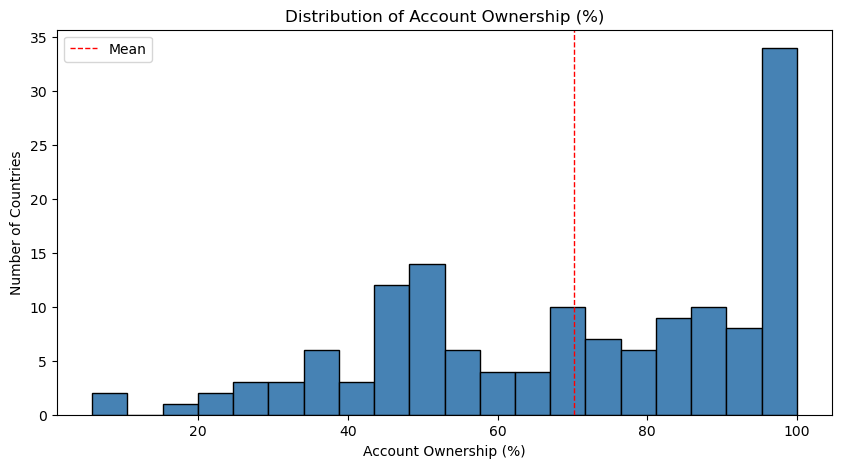

In [51]:
plt.figure(figsize=(10, 5))
plt.hist(df_wb['account_ownership'], bins=20, edgecolor='black',color='steelblue')
plt.title('Distribution of Account Ownership (%)')
plt.xlabel('Account Ownership (%)')
plt.ylabel('Number of Countries')
plt.axvline(df_wb['account_ownership'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.legend()
plt.show()



In [53]:
print(df_wb[df_wb['account_ownership'] > 95].shape)

(34, 4)
